para ver por que la gente se va se me ocurre que tendriamos que ver 
- cuanta gente se ha ido de la empresa MARIA
- si tiene que ver con la antiguedad TotalWorkingYears / YearsAtCompany SARAY
- si tiene que ver con el sueldo DailyRate. ver maximo y minimo y donde se situan, o en las otras columnas de sueldo. PILAR 
- si eran hombres o mujeres CAROL
- la edad que tienen MARIA
- si viajaban o no ELEONORA
- la distancia al trabajo desde casa SARAY
- de que departamento son por si coincide PILAR
- si llevaban mucho tiempo con el mismo responsable o si es el mismo responsable el de todos los que se van CAROL
- si han tenido aumentos de sueldo MARIA
- YearsSinceLastPromotion	 ELEONORA
- su grado de sarisfaccion PILAR
- su job involvment SARAY
- si hacen horas extra MARIA
- WorkLifeBalance CAROL
- TrainingTimesLastYea SARAY
- calcular diferencia entre salario neto y bruto PILAR
- stock_option_level se refiere al nivel de opciones sobre acciones que la compañía ofrece a un empleado como parte de su compensación. Ver si los que dimitieron tenian acciones ELEONORA

- PODEIS AÑADIR MÁS CONSULTAS... PROPONERLAS POR WHATSAPP


In [31]:
# Conclusiones del análisis descriptivo (variables categóricas):
# - La mayoría de los empleados que han dejado la empresa (attrition = Yes) son hombres (84.8%).
# - La mayoría raramente viajan, son de dpto de research & development
# - La mayoría son solteros, hacen horas extra y trabajan en laboratorio tecnico.
# - La maypría han estudiado life_sciences


In [32]:
# num_companies_worked	y total_working_years pueden tener relacion,
# ya que ambas variables se refieren a la experiencia laboral del empleado.
# Es posible que un empleado que ha trabajado en muchas empresas
# también tenga muchos años de experiencia laboral.
# Sin embargo, no es una regla estricta, ya que un empleado podría haber trabajado
# en pocas empresas pero haber acumulado muchos años de experiencia en esas empresas.
# Por lo tanto, aunque estas variables pueden estar relacionadas, no necesariamente lo están
# en todos los casos.
# Sería útil analizar la correlación entre estas variables
# para entender mejor su relación en el contexto de este dataset específico.

#### ¿LAS PERSONAS QUE HAN DEJADO LA EMPRESA ERAN DEL MISMO DEPARTAMENTO?

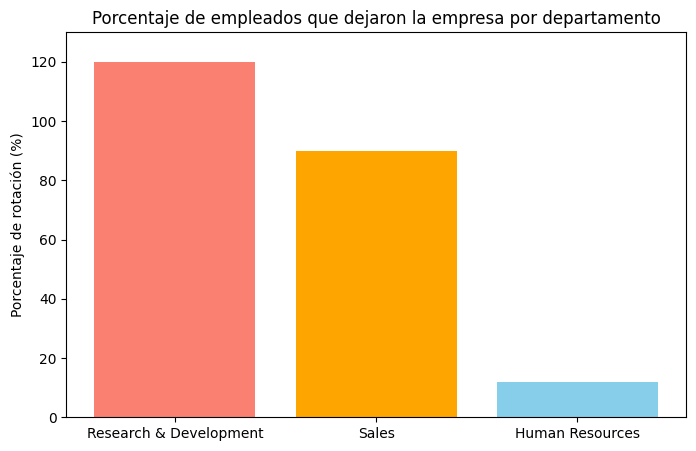

In [33]:
import matplotlib.pyplot as plt

# Porcentajes que me diste
departments = ['Research & Development', 'Sales', 'Human Resources']
attrition_percent = [120, 90, 12]  # aproximado según tus datos

plt.figure(figsize=(8,5))
plt.bar(departments, attrition_percent, color=['salmon','orange','skyblue'])
plt.title('Porcentaje de empleados que dejaron la empresa por departamento')
plt.ylabel('Porcentaje de rotación (%)')
plt.ylim(0, 130)
plt.show()

#####  Research & Development (innovación, creación y mejora de productos o servicios),tiene muchas más renuncias que otros departamentos; el 120 % , le sigue Sales ( Se encarga de vender productos o servicios de la empresa.) con algo mas del 90 % mientras que Recursos Humanos ente el 10, 15 %.  
Con esos porcentajes que mencionas, podemos ver claramente un patrón de rotación de empleados muy desigual por departamento:

   Research & Development (R&D) → >120% ; Esto indica que es el departamento con más renuncias, probablemente por alta presión, carga de trabajo o búsqueda de mejores oportunidades.

   Sales (Ventas) → ~90% ; También alto, lo que puede reflejar metas exigentes o volatilidad en el desempeño por comisiones.

   Recursos Humanos (HR) → 10–15%; Mucho más bajo, lo que sugiere estabilidad y menor presión comparada con R&D y Sale

   

   Este gráfico deja muy claro que R&D es el área crítica para retención de empleados, seguido de Sales, mientras que HR es estable.

### ¿LA ROTACION EN LA EMPRESA ESTA RELACIONADA CON EL SUELDO MONTHLY INCOME ( INGRESO MENSUAL)? ANALIZAR MAXIMO Y MINIMO, EL PROMEDIO DEL SUELDO.

In [34]:
# filtro empleados que dejaron la empresa
# Empleados que dejaron la empresa
attrition_yes = df[df['attrition'] == 'Yes']

# Empleados que se quedaron
attrition_no = df[df['attrition'] == 'No']

In [35]:
#Revisar máximo, mínimo y promedio del sueldo


# Monthly income
print("\nMonthly Income de los que se fueron:")
print("Min:", attrition_yes['monthly_income'].min())
print("Max:", attrition_yes['monthly_income'].max())
print("Promedio:", attrition_yes['monthly_income'].mean())


Monthly Income de los que se fueron:
Min: 1009.0
Max: 19859.0
Promedio: 4757.278481012659


In [36]:
# Empleados que se quedaron
attrition_no = df[df['attrition'] == 'No']

print("Monthly Income de los que se quedaron:")
print("Min:", attrition_no['monthly_income'].min())
print("Max:", attrition_no['monthly_income'].max())
print("Promedio:", attrition_no['monthly_income'].mean())

Monthly Income de los que se quedaron:
Min: 1051.0
Max: 19999.0
Promedio: 6815.333333333333


### Los que permanecen ganan, en promedio, unos 2,000 € más al mes que los que se van. Esto indica que el salario sí influye en la rotación.
La rotación parece mayor entre empleados con salarios medios y bajos.

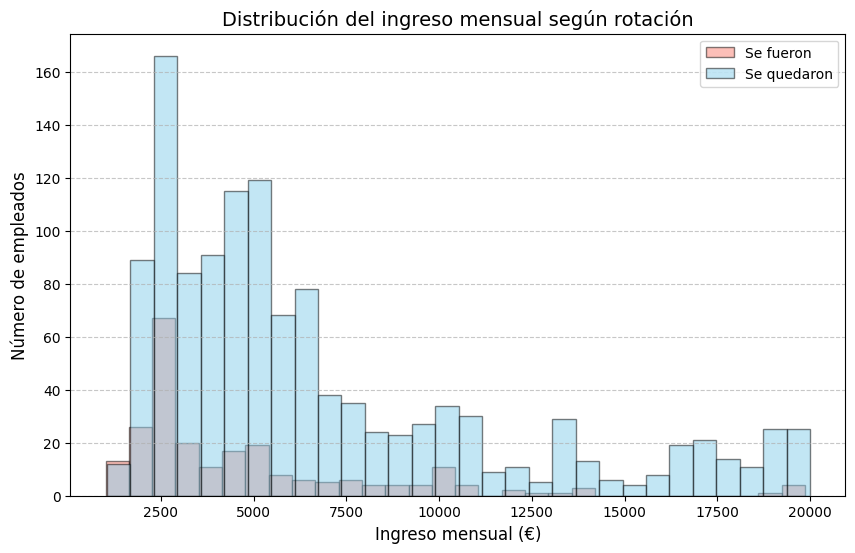

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Histograma de los que se fueron
plt.hist(attrition_yes['monthly_income'], bins=30, alpha=0.5, 
         label='Se fueron', color='salmon', edgecolor='black')

# Histograma de los que se quedaron
plt.hist(attrition_no['monthly_income'], bins=30, alpha=0.5, 
         label='Se quedaron', color='skyblue', edgecolor='black')

plt.title('Distribución del ingreso mensual según rotación', fontsize=14)
plt.xlabel('Ingreso mensual (€)', fontsize=12)
plt.ylabel('Número de empleados', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### El análisis de la distribución del ingreso mensual muestra que los empleados que abandonan la empresa se concentran principalmente en los rangos salariales bajos y medios. Por el contrario, los empleados con ingresos más altos tienden a permanecer en la organización. Esto sugiere que el salario es un factor relevante en la rotación, aunque no el único, ya que también se observan salidas en niveles salariales elevados.

### Sí hay relación entre salario y rotación

###  ANALISIS DEL GRADO DE SATISFACCION  Y SU RELACION CON LA ROTACION EN LA EMPRESA

##Primero, comparo el promedio de satisfacción entre los que se fueron y los que se quedaron:

In [38]:
# Promedio de satisfacción laboral
print("Satisfacción laboral (job_satisfaction):")

print("\nSe fueron:")
print(attrition_yes['job_satisfaction'].mean())

print("\nSe quedaron:")
print(attrition_no['job_satisfaction'].mean())

Satisfacción laboral (job_satisfaction):

Se fueron:
2.481012658227848

Se quedaron:
2.786699107866991


     Se quedaron: 2.79
     Se fueron: 2.48
     La diferencia es pequeña ; 0.31 puntos
     Los que se van tienen menor satisfacción, no es una diferencia muy grande, pero si es clara.
     Por lo que se puede afirmar la satisfacción sí influye en la rotación. Pero no explica todo el  fenómeno. Hay otros factores combinados, como el salario y el departamento en el que se trabaja.

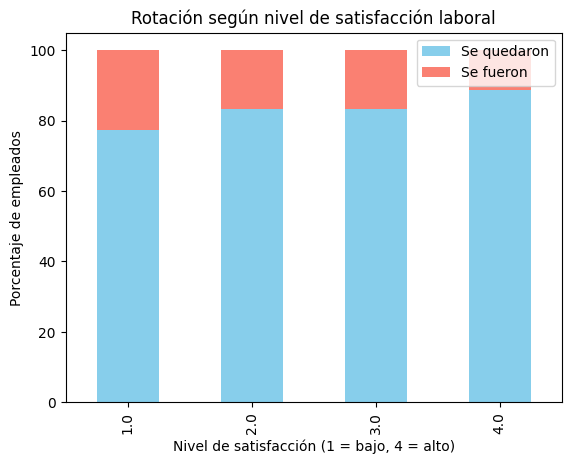

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear tabla cruzada
tabla = pd.crosstab(df['job_satisfaction'], df['attrition'])

# Convertir a porcentaje
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

# Graficar
tabla_pct.plot(kind='bar', stacked=True, color=['skyblue','salmon'])

plt.title('Rotación según nivel de satisfacción laboral')
plt.xlabel('Nivel de satisfacción (1 = bajo, 4 = alto)')
plt.ylabel('Porcentaje de empleados')
plt.legend(['Se quedaron', 'Se fueron'])
plt.show()

# Te muestra:

Para cada nivel (1, 2, 3, 4)
Qué % se queda vs se va

 Aquí verás claramente si:

Nivel 1 → mucha gente se va

Nivel 4 → casi nadie se va

# Calcular la diferencia entre el salario bruto y el salario neto.

In [45]:
#  EL "monthly_income" EL SALARIO MENSUAL SUELE SER EL BRUTO.  COMO NO TENEMOS COLUMNA DE SALARIO NETO PODEMOS 
#  CALCULARLO POR EL BRUTO ( NORMALAMENTE 70-80% ). UTILIZAREMOS EL 75%.

# Estimación de neto
df['net_income_est'] = df['monthly_income'] * 0.75

# Diferencia
df['diferencia_salario'] = df['monthly_income'] - df['net_income_est']

# Estadísticas
print("Diferencia estimada salario bruto - neto (75% neto):")
print("Mínimo:", df['diferencia_salario'].min())
print("Máximo:", df['diferencia_salario'].max())
print("Promedio:", df['diferencia_salario'].mean())

Diferencia estimada salario bruto - neto (75% neto):
Mínimo: 252.25
Máximo: 4999.75
Promedio: 1620.8811224489796


####  Mínimo: 252,25 € → empleados con sueldos bajos
####  Máximo: 4,999,75 € → empleados con sueldos muy altos
####  Promedio: 1,620,88 € → en promedio los empleados pagan esta cantidad en impuestos y retenciones

####  Para los sueldos bajos (1.000 € al mes)
####  Diferencia = 250 €
#### Salario neto = 750 €
#### Esto puede hacer que la rotación sea más alta, porque el empleado percibe mucho menos de lo que aparece como “bruto”.

####  Para los sueldos altos (20.000 € al mes)
####  Diferencia = 5.000 €
####  Salario neto = 15.000 €
####  Aquí, aunque la diferencia es grande en valor absoluto, el porcentaje neto sigue siendo alto, por lo que el impacto en rotación suele ser menor que en los sueldos bajos.


In [48]:
#Podemos hacer un gráfico comparativo mostrando:

# Diferencia bruto-neto para los que se fueron vs los que se quedaron#
# Esto nos dirá si los empleados que se van sienten que su sueldo neto es insuficiente.


C:\Users\Pilar\AppData\Local\Temp\ipykernel_16472\2649492197.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attrition_yes['diferencia_salario'] = attrition_yes['monthly_income'] * 0.25  # 25% retenido
C:\Users\Pilar\AppData\Local\Temp\ipykernel_16472\2649492197.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attrition_no['diferencia_salario'] = attrition_no['monthly_income'] * 0.25
C:\Users\Pilar\AppData\Local\Temp\ipykernel_16472\2649492197.py:9: MatplotlibDeprecationWarning: The 'labels' paramete

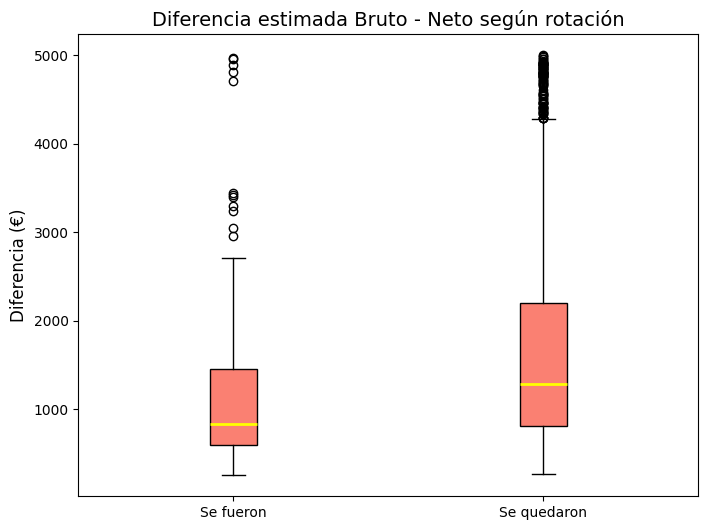

In [49]:
import matplotlib.pyplot as plt

# Calcular la diferencia estimada si no hay columna neta
attrition_yes['diferencia_salario'] = attrition_yes['monthly_income'] * 0.25  # 25% retenido
attrition_no['diferencia_salario'] = attrition_no['monthly_income'] * 0.25

# Crear gráfico
plt.figure(figsize=(8,6))
plt.boxplot([attrition_yes['diferencia_salario'], attrition_no['diferencia_salario']],
            labels=['Se fueron', 'Se quedaron'],
            patch_artist=True,
            boxprops=dict(facecolor='salmon', color='black'),
            medianprops=dict(color='yellow', linewidth=2),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'))

plt.title('Diferencia estimada Bruto - Neto según rotación', fontsize=14)
plt.ylabel('Diferencia (€)', fontsize=12)
plt.show()

###  Mediana
     Compara si los que se fueron tienen mediana más alta o más baja.
###  Rango
     Observa si los empleados que se van tienen mayores diferencias en bruto-neto, especialmente en sueldos bajos.
###  Valores atípicos
    Podrás ver si hay empleados que se van con sueldos muy altos, lo que puede indicar que otros factores (satisfacción, horas extra) también influyen.     